<a href="https://colab.research.google.com/github/aryancodes12/Advance-Machine-Learning/blob/main/expense_segmention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
filepath = "/content/drive/MyDrive/CDPL SEM 3/dataset/Customers_Income_Dining_Expense_KMeans.xlsx"

In [53]:
import pandas as pd

data = pd.read_excel(filepath)

df = pd.DataFrame(data)

In [54]:
df.head()

,Annual Income (₹ Lakhs),Annual Dining Expense (₹ Thousands)
0,6.7,68.5
1,2.6,39.5
2,2.6,28.5
3,14.8,144.2
4,9.1,105.8


In [55]:
df.shape

(200, 2)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Annual Income (₹ Lakhs)              200 non-null    float64
 1   Annual Dining Expense (₹ Thousands)  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [57]:
df.columns

Index(['Annual Income (₹ Lakhs)', 'Annual Dining Expense (₹ Thousands)'], dtype='object')

In [58]:
df.describe()

,Annual Income (₹ Lakhs),Annual Dining Expense (₹ Thousands)
count,200.000000,200.000000
mean,8.258500,85.749000
std,4.364478,43.366994
min,1.600000,11.700000
25%,4.300000,48.800000
50%,7.900000,81.950000
75%,12.375000,124.150000
max,16.900000,168.500000


In [59]:
df.isnull().sum()

,0
Annual Income (₹ Lakhs),0
Annual Dining Expense (₹ Thousands),0


# Visualization

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

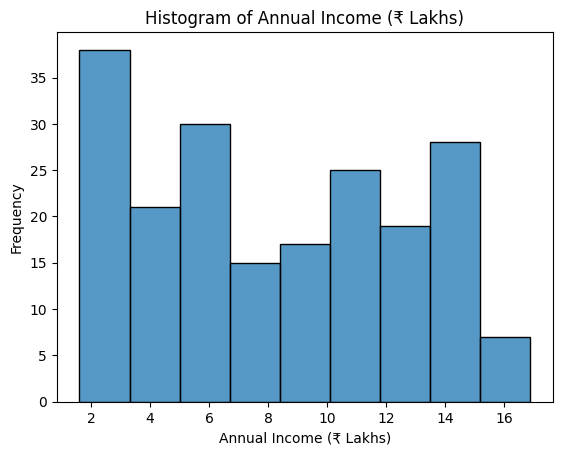

In [61]:
sns.histplot(df['Annual Income (₹ Lakhs)'])
plt.title("Histogram of Annual Income (₹ Lakhs)")
plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Frequency")
plt.show()

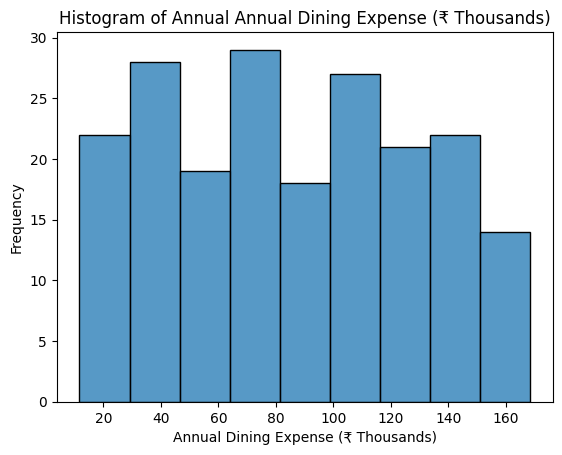

In [62]:
sns.histplot(df['Annual Dining Expense (₹ Thousands)'])
plt.title("Histogram of Annual Annual Dining Expense (₹ Thousands)")
plt.xlabel("Annual Dining Expense (₹ Thousands)")
plt.ylabel("Frequency")
plt.show()

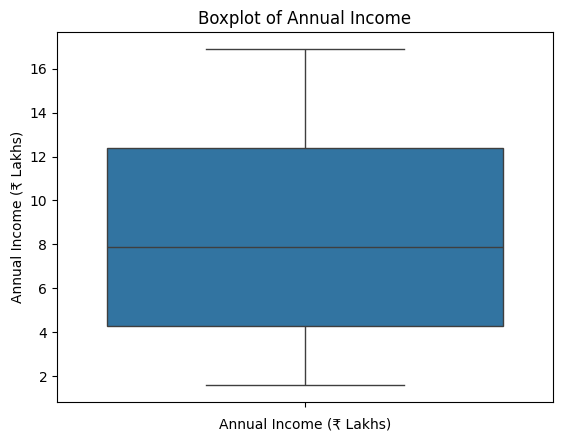

In [63]:
sns.boxplot(df['Annual Income (₹ Lakhs)'])
plt.title("Boxplot of Annual Income")
plt.xlabel("Annual Income (₹ Lakhs)")
plt.show()

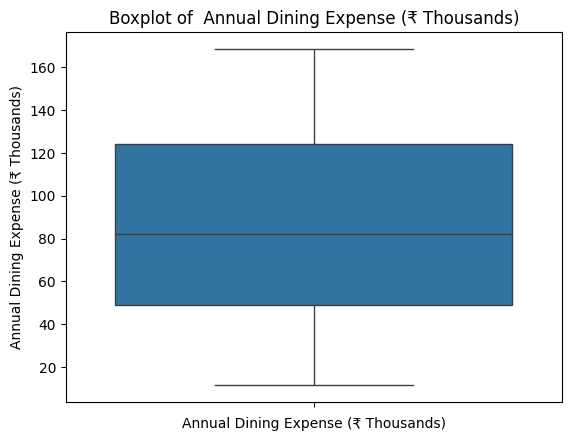

In [64]:
sns.boxplot(df['Annual Dining Expense (₹ Thousands)'])
plt.title("Boxplot of  Annual Dining Expense (₹ Thousands)")
plt.xlabel("Annual Dining Expense (₹ Thousands)")
plt.show()

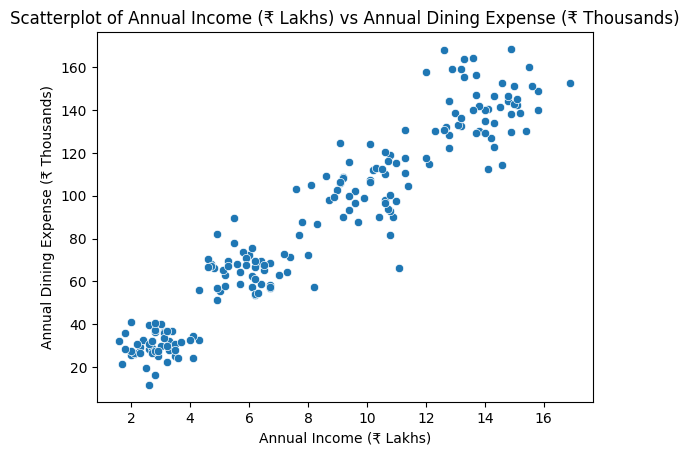

In [65]:
sns.scatterplot(data = df, x='Annual Income (₹ Lakhs)', y='Annual Dining Expense (₹ Thousands)')
plt.title("Scatterplot of Annual Income (₹ Lakhs) vs Annual Dining Expense (₹ Thousands)")
plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Annual Dining Expense (₹ Thousands)")
plt.show()

In [66]:
import numpy as np
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
  kmeans = KMeans(n_clusters = k, random_state=42)
  kmeans.fit(df)
  wcss.append(kmeans.inertia_)

print(wcss)

[378049.22535, 85118.99835783584, 46656.43551455028, 17007.700593197278, 11565.62550531632, 7977.795547899164, 6577.91828868394, 5622.782588999092, 4175.105393267653, 3053.603663166341]


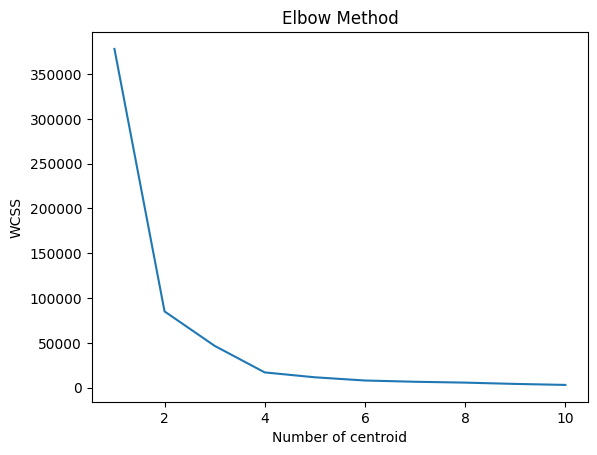

In [67]:
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of centroid")
plt.ylabel("WCSS")
plt.show()

In [68]:
y_kmeans = KMeans(n_clusters = 4, random_state=42)
kmeans = y_kmeans.fit_predict(df)

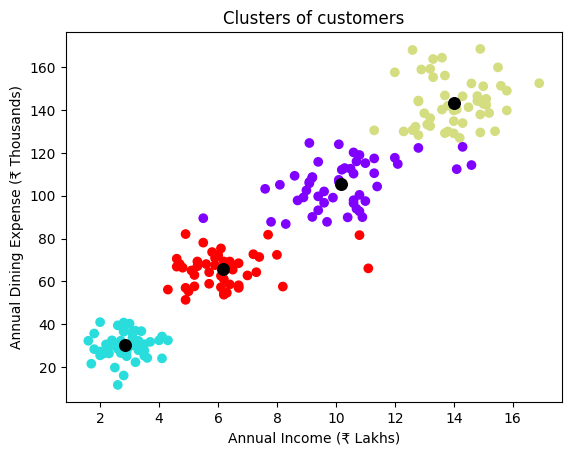

In [70]:
plt.scatter(data = df, x= 'Annual Income (₹ Lakhs)', y = "Annual Dining Expense (₹ Thousands)", c = kmeans, cmap = 'rainbow')
plt.scatter(y_kmeans.cluster_centers_[:, 0],
            y_kmeans.cluster_centers_[:, 1],
            s = 70, c = 'black', label = 'Centroids')

plt.title("Clusters of customers")
plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Annual Dining Expense (₹ Thousands)")
plt.show()

high income + high expense =

In [71]:
df['clusters'] = kmeans

In [72]:
df.head()

,Annual Income (₹ Lakhs),Annual Dining Expense (₹ Thousands),clusters
0,6.7,68.5,3
1,2.6,39.5,1
2,2.6,28.5,1
3,14.8,144.2,2
4,9.1,105.8,0
